# 📘 Chapter 4: Training Models
### *Hands-On ML with Scikit-Learn, Keras & TensorFlow — Aurélien Géron*

---

> **What this chapter covers:**
> We open the black box! Until now we've used models without understanding *how* they learn.
> This chapter explains the maths and mechanics of learning from scratch.

> 🗺️ **Chapter Roadmap:**
> 1. Linear Regression — the closed-form solution
> 2. Gradient Descent — how models actually learn
> 3. Polynomial Regression — fitting curves, not just lines
> 4. Regularisation — Ridge, Lasso, Elastic Net
> 5. Logistic Regression — classification with probabilities
> 6. Softmax Regression — multiclass logistic regression

---


## 🔧 Setup — Imports

In [1]:
import numpy as np                          # Fast numerical arrays and matrix operations
import pandas as pd                          # Data tables (DataFrames)
import matplotlib.pyplot as plt              # Plotting library
import matplotlib.gridspec as gridspec       # Fine-grained subplot layout control
import warnings                              # Control warning messages
warnings.filterwarnings('ignore')            # Suppress noisy warnings

from sklearn.linear_model import (
    LinearRegression,       # Ordinary least-squares linear regression
    Ridge,                  # Linear regression with L2 regularisation (penalises large weights)
    Lasso,                  # Linear regression with L1 regularisation (drives weights to zero)
    ElasticNet,             # Combines L1 + L2 regularisation
    LogisticRegression,     # Classification via logistic (sigmoid) function
    SGDRegressor,           # Linear regression trained with Stochastic Gradient Descent
    SGDClassifier,          # Linear classifier trained with Stochastic Gradient Descent
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler  # Feature transforms
from sklearn.pipeline import Pipeline                                  # Chain steps together
from sklearn.model_selection import train_test_split                   # Split data
from sklearn.datasets import make_classification                       # Generate synthetic data
from sklearn.metrics import mean_squared_error                         # Regression error metric

# Consistent plot styling
plt.rcParams['figure.facecolor'] = 'white'   # White figure background
plt.rcParams['axes.facecolor']   = '#f8f9fa' # Light grey axes background
plt.rcParams['axes.grid']        = True      # Show gridlines
plt.rcParams['grid.alpha']       = 0.35      # Subtle gridlines
plt.rcParams['lines.linewidth']  = 2         # Slightly thicker lines by default

print("✅ All imports successful!")


✅ All imports successful!


## 1. 📏 Linear Regression

Linear Regression is the simplest model of all — it fits a **straight line** through data.

> 🟦 **Linear Regression Model:**
> $$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$
>
> - $\hat{y}$ = the model's prediction
> - $\theta_0$ = the **bias** (y-intercept — where the line crosses the y-axis)
> - $\theta_1 \ldots \theta_n$ = the **weights** (how much each feature moves the prediction)
> - $x_1 \ldots x_n$ = the input **features**

In matrix form this is simply: $\hat{y} = X \cdot \boldsymbol{\theta}$

### How does it learn? — The Normal Equation

> 🟦 **Normal Equation:** A closed-form (direct) formula that gives the exact optimal weights in one step — no iteration needed.
> $$\hat{\boldsymbol{\theta}} = (X^T X)^{-1} X^T y$$

**Pros:** Exact solution in one calculation  
**Cons:** Very slow when there are millions of features (matrix inversion is expensive)

> 🟦 **MSE (Mean Squared Error):** The cost function Linear Regression minimises — average of squared prediction errors.
> $$MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$


In [2]:
# Generate synthetic data: y = 4 + 3x + Gaussian noise
np.random.seed(42)                              # Fix seed so results are reproducible
m = 100                                         # Number of training examples
X = 2 * np.random.rand(m, 1)                   # Random features uniformly distributed in [0, 2]
y = 4 + 3 * X.ravel() + np.random.randn(m)    # True relationship: y = 4 + 3x, plus noise
# .ravel() converts the (100,1) column vector to a flat (100,) array

# ── Fit using Scikit-Learn (internally uses the Normal Equation / SVD) ───
lin_reg = LinearRegression()        # Create the model object
lin_reg.fit(X, y)                   # Fit: find optimal theta using the Normal Equation

print("=" * 45)
print("  Linear Regression — Learned Parameters")
print("=" * 45)
print(f"  Bias (θ₀, intercept): {lin_reg.intercept_:.4f}  (true value: 4.0)")
print(f"  Weight (θ₁, slope):   {lin_reg.coef_[0]:.4f}  (true value: 3.0)")
# .intercept_ -> the learned bias term (θ₀)
# .coef_       -> array of learned weights (θ₁, θ₂, ...)
print()
print("The model learned values very close to the true values (4 and 3)!")

# ── Implement the Normal Equation manually to see how it works ───────────
X_b = np.c_[np.ones((m, 1)), X]   # Add a column of 1s for the bias term
# np.c_ -> concatenate arrays column-wise
# np.ones((m,1)) -> column of 1s; when multiplied by θ₀ gives the bias
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
# @        -> matrix multiplication operator
# X_b.T   -> transpose of X_b
# np.linalg.inv(...) -> matrix inverse
# Full formula: θ = (XᵀX)⁻¹ Xᵀy
print()
print("Normal Equation (manual calculation):")
print(f"  θ₀ (bias):   {theta_best[0]:.4f}")
print(f"  θ₁ (weight): {theta_best[1]:.4f}")
print("  ✅ Same result as sklearn!")


  Linear Regression — Learned Parameters
  Bias (θ₀, intercept): 4.2151  (true value: 4.0)
  Weight (θ₁, slope):   2.7701  (true value: 3.0)

The model learned values very close to the true values (4 and 3)!

Normal Equation (manual calculation):
  θ₀ (bias):   4.2151
  θ₁ (weight): 2.7701
  ✅ Same result as sklearn!


# Mean Squared Error (MSE)

What it is:The average of the squared differences between predicted values and actual values.

In simple terms:
“How wrong are we, on average, if we punish bigger mistakes more?”
Key idea:
Errors are squared → large errors get punished heavily
Units are squared (e.g., dollars²), which can feel less intuitive

# Root Mean Squared Error (RMSE)

What it is:The square root of MSE.
In simple terms:
“How wrong are we, on average, in the original unit?”

When to use each
MSE
Good for model training (used in loss functions)
Strongly penalizes large errors

RMSE
Better for reporting to business/stakeholders
More interpretable

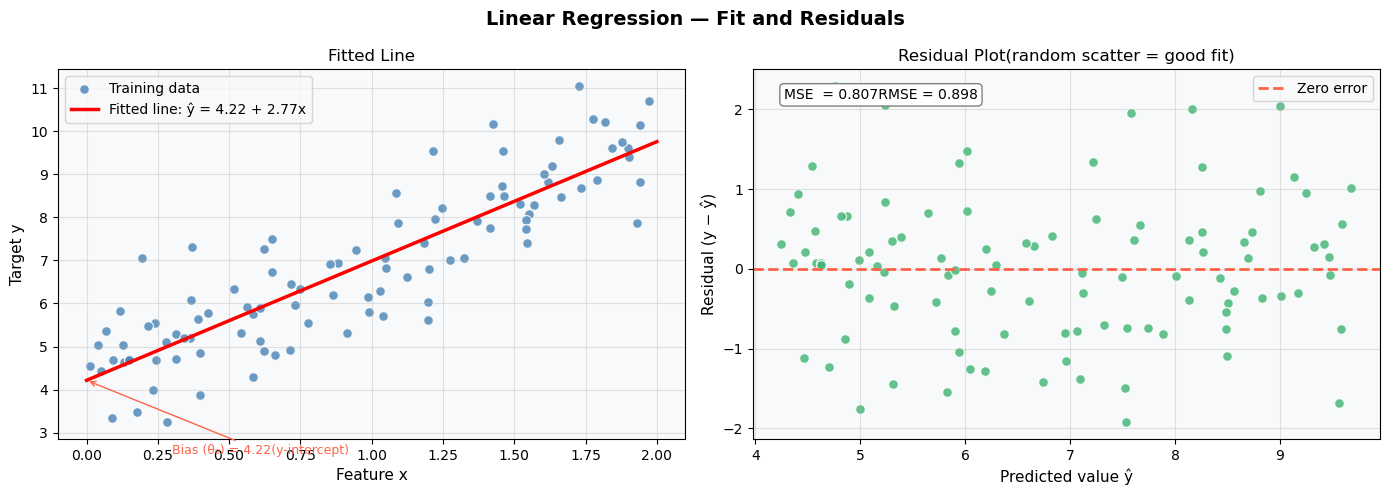

MSE = 0.8066  |  RMSE = 0.8981
💡 Residuals look random — no curved pattern — so linear is a good fit here!


In [5]:
# Visualise the fitted line and residuals
X_new = np.array([[0], [2]])              # Two points to draw the prediction line
y_pred_line = lin_reg.predict(X_new)      # Predict at x=0 and x=2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Linear Regression — Fit and Residuals", fontsize=14, fontweight='bold')

# ── Left: scatter plot with fitted line ──────────────────────────────────
ax = axes[0]
ax.scatter(X, y, color='steelblue', edgecolors='white', s=50, alpha=0.8, label='Training data')
ax.plot(X_new, y_pred_line, 'r-', lw=2.5, label=f'Fitted line: ŷ = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f}x')
ax.set_xlabel("Feature x", fontsize=11)
ax.set_ylabel("Target y", fontsize=11)
ax.set_title("Fitted Line", fontsize=12)
ax.legend()

# Annotate bias and slope on the plot
ax.annotate(f"Bias (θ₀) = {lin_reg.intercept_:.2f}(y-intercept)",
            xy=(0, lin_reg.intercept_), xytext=(0.3, 2.5),
            arrowprops=dict(arrowstyle='->', color='tomato'),
            color='tomato', fontsize=9)

# ── Right: residual plot (errors should be random — no pattern) ──────────
ax = axes[1]
y_pred_all = lin_reg.predict(X)          # Predictions for all training points
residuals = y - y_pred_all               # Residual = actual - predicted

ax.scatter(y_pred_all, residuals, color='mediumseagreen', edgecolors='white', s=50, alpha=0.8)
ax.axhline(0, color='tomato', lw=2, linestyle='--', label='Zero error')
# A good model has residuals scattered randomly around zero — no pattern
ax.set_xlabel("Predicted value ŷ", fontsize=11)
ax.set_ylabel("Residual (y − ŷ)", fontsize=11)
ax.set_title("Residual Plot(random scatter = good fit)", fontsize=12)
ax.legend()

# Calculate and display MSE and RMSE
mse  = mean_squared_error(y, y_pred_all)  # Mean Squared Error
rmse = np.sqrt(mse)                        # Root Mean Squared Error (same units as y)
ax.text(0.05, 0.95, f"MSE  = {mse:.3f}RMSE = {rmse:.3f}",
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', fc='white', ec='gray'), fontsize=10)

plt.tight_layout()
plt.savefig("ch04_01_linear_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"MSE = {mse:.4f}  |  RMSE = {rmse:.4f}")
print("💡 Residuals look random — no curved pattern — so linear is a good fit here!")


## 2. ⛰️ Gradient Descent

The Normal Equation becomes impossibly slow with many features. Enter **Gradient Descent** — the engine behind almost all ML algorithms.

> 🟦 **Gradient Descent:** An iterative optimisation algorithm that:
> 1. Starts with random parameter values
> 2. Calculates the gradient (slope) of the cost function
> 3. Takes a small step in the **opposite** direction (downhill)
> 4. Repeats until it reaches the minimum

**Analogy:** You're lost in the mountains at night. To find the valley (minimum cost), you feel the slope beneath your feet and take a step in the steepest downward direction. Repeat until you can't go lower.

> 🟦 **Learning Rate (η):** Controls how big each step is.
> - Too small -> very slow convergence
> - Too large -> overshoots the minimum, may diverge
> - Just right -> fast and stable convergence

### Three flavours of Gradient Descent:

| Type | Uses per step | Speed | Noise |
|---|---|---|---|
| **Batch GD** | All training examples | Slow | Smooth |
| **Stochastic GD (SGD)** | 1 random example | Fast | Very noisy |
| **Mini-batch GD** | Small random batch (e.g. 32) | Middle | Some noise |


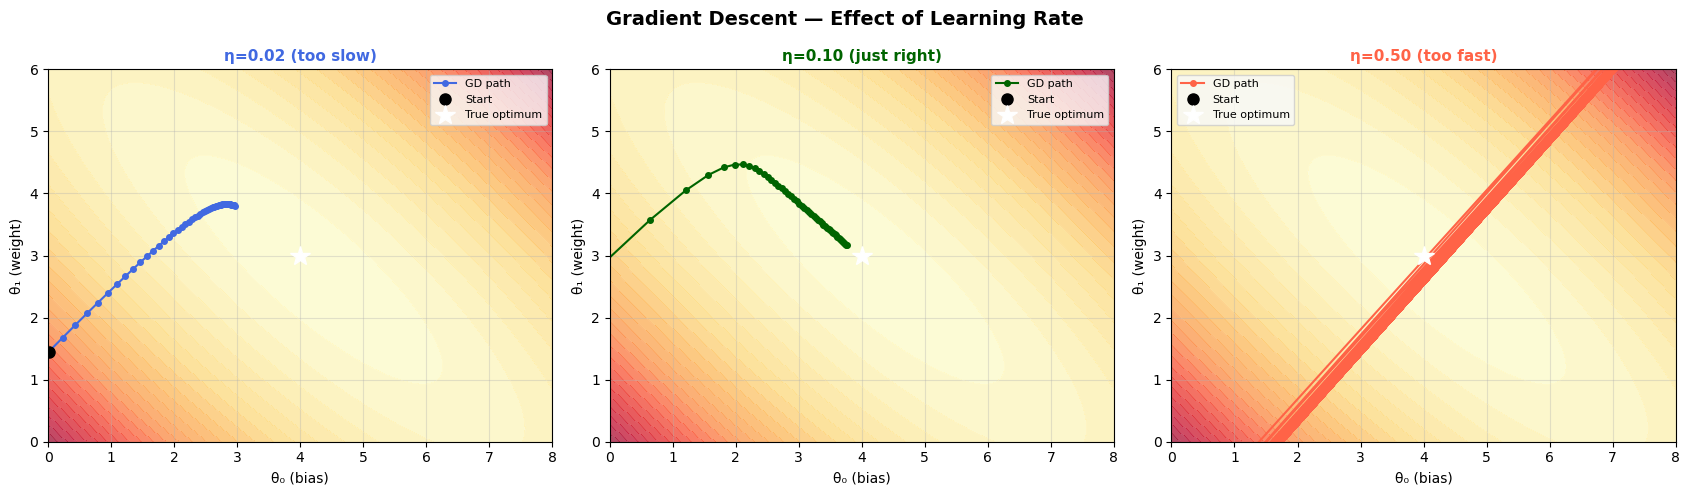

💡 The star ★ marks the true optimum (θ₀=4, θ₁=3).
   Too slow -> takes forever | Just right -> converges cleanly | Too fast -> overshoots!


In [6]:
# Visualise Gradient Descent — the intuition behind learning
import numpy as np
import matplotlib.pyplot as plt

# Use our earlier 1D dataset
np.random.seed(42)
m = 100
X_gd = 2 * np.random.rand(m, 1)
y_gd = 4 + 3 * X_gd.ravel() + np.random.randn(m)
X_b_gd = np.c_[np.ones((m, 1)), X_gd]   # Add bias column of 1s

# ── Define the MSE cost function over a grid of (θ₀, θ₁) values ─────────
def compute_mse(theta, X_b, y):  # Compute MSE for given parameter vector theta
    predictions = X_b @ theta     # Matrix multiply: X_b (m×2) @ theta (2,) -> predictions (m,)
    errors = predictions - y      # Prediction errors
    return (errors ** 2).mean()   # Mean of squared errors

# Build a grid of cost values for visualisation
theta0_vals = np.linspace(0, 8, 100)   # Range of bias values to try
theta1_vals = np.linspace(0, 6, 100)   # Range of weight values to try
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)  # Create 2D grid for contour plot
# np.meshgrid -> turns two 1D arrays into two 2D arrays covering all combinations
Cost = np.array([[compute_mse(np.array([t0, t1]), X_b_gd, y_gd)
                  for t0 in theta0_vals]
                 for t1 in theta1_vals])

# ── Run Batch Gradient Descent and record the path ───────────────────────
def batch_gradient_descent(X_b, y, learning_rate=0.1, n_iterations=50):  # Run batch GD and return the parameter path
    theta = np.random.randn(2)     # Start from a random point
    path  = [theta.copy()]         # Record starting position
    m     = len(y)
    for _ in range(n_iterations):
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        # Gradient of MSE w.r.t. theta:
        #   d(MSE)/d(theta) = (2/m) * Xᵀ(Xθ - y)
        # This tells us the "slope" of the cost surface at the current theta
        theta = theta - learning_rate * gradients
        # Move in the opposite direction of the gradient (downhill)
        # learning_rate controls the step size
        path.append(theta.copy())  # Record new position
    return np.array(path)          # Shape: (n_iterations+1, 2)

paths = {
    'η=0.02 (too slow)': batch_gradient_descent(X_b_gd, y_gd, learning_rate=0.02),
    'η=0.10 (just right)': batch_gradient_descent(X_b_gd, y_gd, learning_rate=0.10),
    'η=0.50 (too fast)': batch_gradient_descent(X_b_gd, y_gd, learning_rate=0.50),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Gradient Descent — Effect of Learning Rate", fontsize=14, fontweight='bold')

colors = ['royalblue', 'darkgreen', 'tomato']
for ax, (label, path), color in zip(axes, paths.items(), colors):
    # Draw cost contours
    contour = ax.contourf(T0, T1, Cost, levels=30, cmap='YlOrRd', alpha=0.7)
    ax.contour(T0, T1, Cost, levels=30, colors='white', alpha=0.3, linewidths=0.5)

    # Plot the descent path
    ax.plot(path[:, 0], path[:, 1], 'o-',
            color=color, markersize=4, lw=1.5, label='GD path')
    ax.plot(path[0, 0], path[0, 1], 'ko', markersize=8, label='Start')    # Starting point
    ax.plot(4, 3, 'w*', markersize=15, zorder=5, label='True optimum')    # True answer (θ₀=4, θ₁=3)

    ax.set_xlabel("θ₀ (bias)"); ax.set_ylabel("θ₁ (weight)")
    ax.set_title(label, fontsize=11, color=color, fontweight='bold')
    ax.set_xlim(0, 8); ax.set_ylim(0, 6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("ch04_02_gradient_descent.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 The star ★ marks the true optimum (θ₀=4, θ₁=3).")
print("   Too slow -> takes forever | Just right -> converges cleanly | Too fast -> overshoots!")


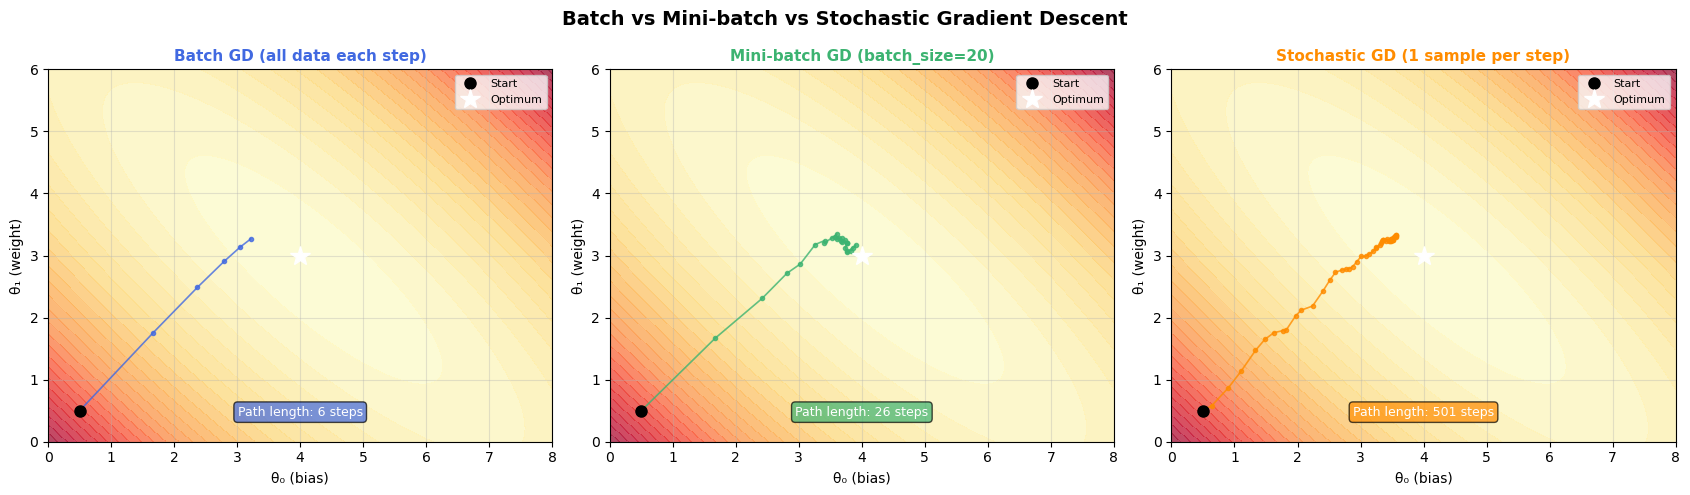

💡 Batch: smooth but slow  |  Mini-batch: good balance  |  SGD: fast but noisy
   In practice, mini-batch GD (batch_size=32–256) is used for most deep learning.


In [7]:
# Compare Batch GD vs Stochastic GD vs Mini-batch GD — the three variants
np.random.seed(42)

def sgd_path(X_b, y, learning_rate=0.1, n_epochs=5, batch_size=1):
    # Generic GD: batch_size=1 -> SGD, batch_size=m -> Batch GD, in between -> mini-batch
    m     = len(y)
    theta = np.array([0.5, 0.5])   # Start from the same point for fair comparison
    path  = [theta.copy()]
    for epoch in range(n_epochs):
        # Shuffle the data each epoch (important for SGD — avoids patterns)
        indices = np.random.permutation(m)
        X_b_shuffled, y_shuffled = X_b[indices], y[indices]
        for i in range(0, m, batch_size):                     # Step through in chunks of batch_size
            xi = X_b_shuffled[i:i+batch_size]                # Mini-batch of features
            yi = y_shuffled[i:i+batch_size]                  # Corresponding labels
            gradients = (2/len(xi)) * xi.T @ (xi @ theta - yi)  # Gradient on this mini-batch
            theta = theta - learning_rate * gradients
            path.append(theta.copy())
    return np.array(path)

m = len(y_gd)
paths_compare = {
    'Batch GD (all data each step)':      sgd_path(X_b_gd, y_gd, batch_size=m,  learning_rate=0.1),
    'Mini-batch GD (batch_size=20)':      sgd_path(X_b_gd, y_gd, batch_size=20, learning_rate=0.1),
    'Stochastic GD (1 sample per step)':  sgd_path(X_b_gd, y_gd, batch_size=1,  learning_rate=0.02),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Batch vs Mini-batch vs Stochastic Gradient Descent", fontsize=14, fontweight='bold')

for ax, (label, path), color in zip(axes, paths_compare.items(),
                                     ['royalblue', 'mediumseagreen', 'darkorange']):
    ax.contourf(T0, T1, Cost, levels=30, cmap='YlOrRd', alpha=0.7)
    ax.contour(T0, T1, Cost, levels=30, colors='white', alpha=0.2, linewidths=0.5)

    # Plot only first 50 steps so the path is visible
    shown = path[:50]
    ax.plot(shown[:, 0], shown[:, 1], 'o-', color=color, markersize=3, lw=1.2, alpha=0.8)
    ax.plot(shown[0, 0],  shown[0, 1],  'ko', markersize=8, label='Start')
    ax.plot(4, 3, 'w*', markersize=15, zorder=5, label='Optimum')
    ax.set_xlabel("θ₀ (bias)"); ax.set_ylabel("θ₁ (weight)")
    ax.set_title(label, fontsize=11, color=color, fontweight='bold')
    ax.set_xlim(0, 8); ax.set_ylim(0, 6)
    ax.legend(fontsize=8)
    ax.text(0.5, 0.07, f"Path length: {len(path)} steps",
            transform=ax.transAxes, ha='center', fontsize=9, color='white',
            bbox=dict(fc=color, alpha=0.7, boxstyle='round'))

plt.tight_layout()
plt.savefig("ch04_03_gd_variants.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Batch: smooth but slow  |  Mini-batch: good balance  |  SGD: fast but noisy")
print("   In practice, mini-batch GD (batch_size=32–256) is used for most deep learning.")


In [8]:
# SGDRegressor — sklearn's implementation of SGD for regression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sgd_reg = Pipeline([
    ('scaler', StandardScaler()),          # Scale features FIRST — SGD is very sensitive to scale
    ('sgd',    SGDRegressor(
        max_iter=1000,                     # Maximum number of epochs (passes over data)
        tol=1e-5,                          # Stop early if improvement < tol
        penalty=None,                      # No regularisation for now
        eta0=0.01,                         # Initial learning rate
        random_state=42
    ))
])

sgd_reg.fit(X_gd, y_gd)    # Train on our synthetic data

# The scaler changes the feature scale, so we need to interpret parameters carefully
print("SGDRegressor (via sklearn):")
print(f"  Intercept: {sgd_reg.named_steps['sgd'].intercept_[0]:.4f}")
print(f"  Coef:      {sgd_reg.named_steps['sgd'].coef_[0]:.4f}")
print()
print("💡 The actual values differ from 4 and 3 because StandardScaler transforms")
print("   the features — but predictions will still be correct on scaled input.")


SGDRegressor (via sklearn):
  Intercept: 6.8211
  Coef:      1.6401

💡 The actual values differ from 4 and 3 because StandardScaler transforms
   the features — but predictions will still be correct on scaled input.


## 3. 🌊 Polynomial Regression

Linear regression only fits straight lines. What if the data has a curve?

> 🟦 **Polynomial Regression:** Add polynomial features (x², x³, …) to the input, then fit a linear model on those features. The model is still *linear in the parameters* — it's the features that become nonlinear.

**Example:** Instead of fitting $y = \theta_0 + \theta_1 x$, we fit:
$$y = \theta_0 + \theta_1 x + \theta_2 x^2$$

> 🟦 **PolynomialFeatures:** A Scikit-Learn transformer that automatically generates polynomial and interaction terms from your existing features.

> 🟨 **Key Insight:** Adding polynomial features is the bridge between linear models and the richer models we'll see later. The same gradient descent machinery works — we just changed the features.


PolynomialFeatures(degree=2) example:
  Before: [-0.75275929]  -> just x
  After:  [-0.75275929  0.56664654]  -> [x, x²]



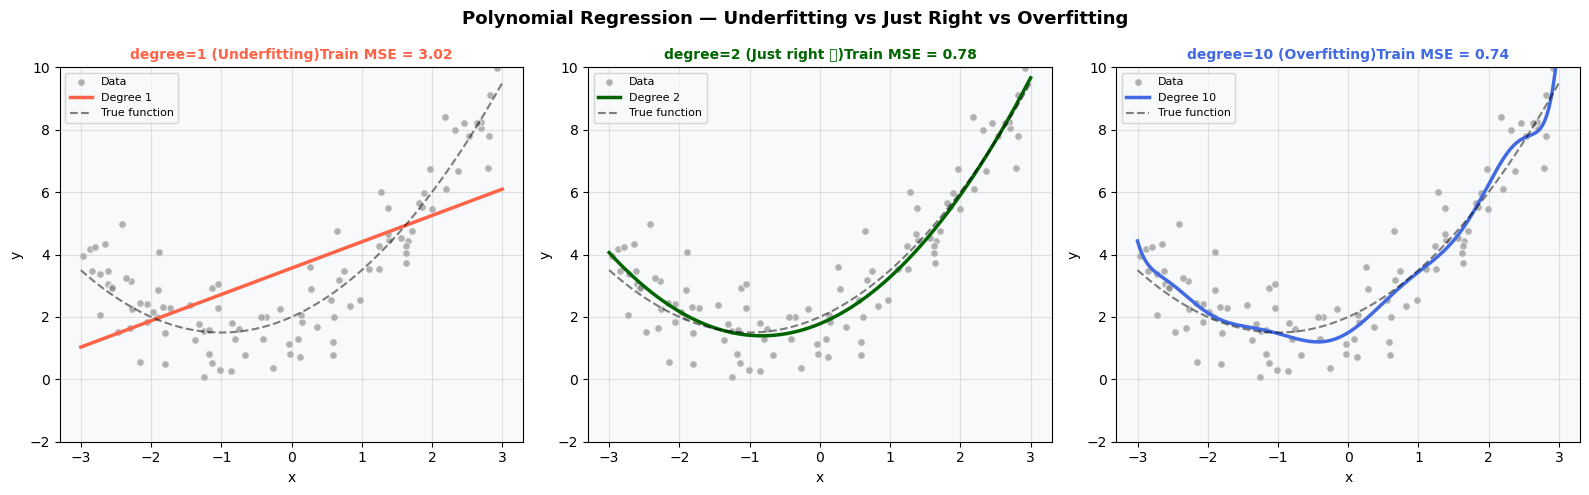

💡 degree=1: straight line misses the curve entirely (underfitting)
   degree=2: matches the true quadratic function well
   degree=10: wiggles to hit every point — won't generalise (overfitting)


In [9]:
# Polynomial Regression — fitting curves with linear models
np.random.seed(42)

# Generate curved data: y = 0.5x² + x + 2 + noise
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3       # Features uniformly in [-3, 3]
y_poly = 0.5 * X_poly.ravel()**2 + X_poly.ravel() + 2 + np.random.randn(m)
# True function is quadratic — a straight line will never fit this well

# ── Show what PolynomialFeatures does ────────────────────────────────────
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2,         # Add up to x² terms
                                   include_bias=False) # sklearn adds its own bias
X_poly_transformed = poly_features.fit_transform(X_poly)
# Input:  [[x₁], [x₂], ...]          shape (m, 1)
# Output: [[x₁, x₁²], [x₂, x₂²], ...] shape (m, 2)

print("PolynomialFeatures(degree=2) example:")
print(f"  Before: {X_poly[0]}  -> just x")
print(f"  After:  {X_poly_transformed[0]}  -> [x, x²]")
print()

# ── Fit models of different degrees ──────────────────────────────────────
degrees = [1, 2, 10]        # Underfitting, just right, overfitting
X_plot  = np.linspace(-3, 3, 300).reshape(-1, 1)  # Fine grid for smooth prediction curves
colors  = ['tomato', 'darkgreen', 'royalblue']
labels  = ['degree=1 (Underfitting)', 'degree=2 (Just right ✅)', 'degree=10 (Overfitting)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Polynomial Regression — Underfitting vs Just Right vs Overfitting",
             fontsize=13, fontweight='bold')

for ax, degree, color, label in zip(axes, degrees, colors, labels):
    # Build pipeline: polynomial features -> standard scaler -> linear regression
    model = Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),    # Scale the polynomial features
        ('lin',    LinearRegression())   # Fit a linear model on the transformed features
    ])
    model.fit(X_poly, y_poly)           # Fit to training data
    y_plot = model.predict(X_plot)      # Predict on fine grid for smooth curve

    ax.scatter(X_poly, y_poly, color='gray', edgecolors='white', s=30, alpha=0.6, label='Data')
    ax.plot(X_plot, y_plot, color=color, lw=2.5, label=f'Degree {degree}')

    # True function for reference
    y_true = 0.5 * X_plot.ravel()**2 + X_plot.ravel() + 2
    ax.plot(X_plot, y_true, 'k--', lw=1.5, alpha=0.5, label='True function')

    # Compute training MSE to quantify fit quality
    train_mse = mean_squared_error(y_poly, model.predict(X_poly))
    ax.set_title(f"{label}Train MSE = {train_mse:.2f}", fontsize=10, color=color, fontweight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_ylim(-2, 10); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("ch04_04_polynomial_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 degree=1: straight line misses the curve entirely (underfitting)")
print("   degree=2: matches the true quadratic function well")
print("   degree=10: wiggles to hit every point — won't generalise (overfitting)")


## 4. 📉 Learning Curves

How do you know if your model is overfitting or underfitting **without** looking at the test set?

> 🟦 **Learning Curve:** A plot of training error and validation error as a function of **training set size**. It reveals whether your model has a bias or variance problem.

### Diagnosing the problem:

| Pattern | Diagnosis | Fix |
|---|---|---|
| Both errors high and close together | **Underfitting** (high bias) | More complex model, add features |
| Training error low, validation error high | **Overfitting** (high variance) | More data, regularisation, simpler model |
| Both errors low and close | **Good fit** ✅ | You're done! |

> 🟨 **Key Takeaway:** If adding more training data doesn't help, you have a high-bias problem (underfitting). If there's a big gap between training and validation errors, you have a high-variance problem (overfitting).


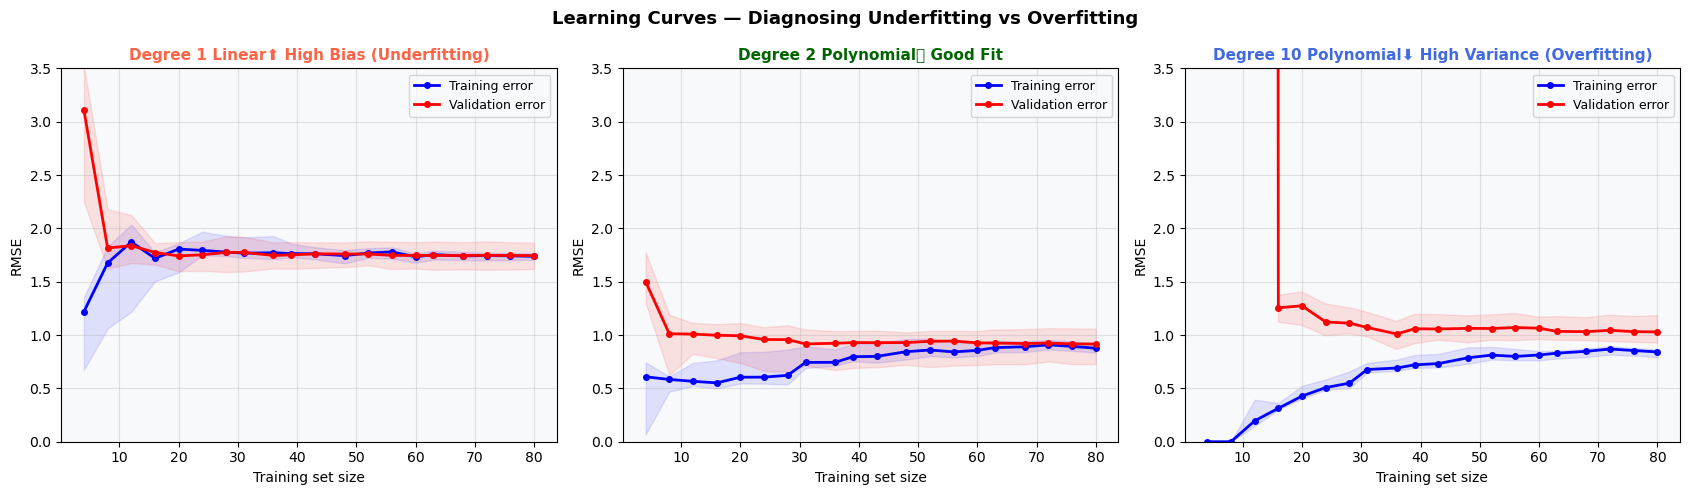

🔍 Reading learning curves:
  Degree 1:  Both errors plateau HIGH -> underfitting (model too simple)
  Degree 2:  Both errors converge LOW -> good generalisation
  Degree 10: Big GAP between train and val -> overfitting (model too complex)


In [10]:
# Learning curves — visualise bias vs variance
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, ax, title, color):  # Plot train vs val error over training sizes
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.05, 1.0, 20),  # From 5% to 100% of training data
        scoring='neg_root_mean_squared_error',     # Negative RMSE (sklearn convention — negate to get positive)
        cv=5,                                      # 5-fold cross-validation for each size
        n_jobs=-1                                  # Parallelise across CPU cores
    )
    # Convert from negative to positive RMSE
    train_rmse = -train_scores.mean(axis=1)   # Mean across the 5 CV folds
    val_rmse   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_rmse, 'b-o', markersize=4, label='Training error')
    ax.plot(train_sizes, val_rmse,   'r-o', markersize=4, label='Validation error')
    ax.fill_between(train_sizes,
                    -train_scores.min(axis=1), -train_scores.max(axis=1),
                    alpha=0.1, color='blue')     # Shaded band = variance across folds
    ax.fill_between(train_sizes,
                    -val_scores.min(axis=1), -val_scores.max(axis=1),
                    alpha=0.1, color='red')
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 3.5)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Learning Curves — Diagnosing Underfitting vs Overfitting", fontsize=13, fontweight='bold')

models = [
    (Pipeline([('lin', LinearRegression())]),                              # Degree 1 — underfits
     "Degree 1 Linear⬆ High Bias (Underfitting)", 'tomato'), (Pipeline([('poly', PolynomialFeatures(2, include_bias=False)),
               ('scaler', StandardScaler()), ('lin', LinearRegression())]), # Degree 2 — good fit
     "Degree 2 Polynomial✅ Good Fit", 'darkgreen'),
(Pipeline([('poly', PolynomialFeatures(10, include_bias=False)),
               ('scaler', StandardScaler()), ('lin', LinearRegression())]), # Degree 10 — overfits
     "Degree 10 Polynomial⬇ High Variance (Overfitting)", 'royalblue'),
]
for ax, (model, title, color) in zip(axes, models):
    plot_learning_curve(model, X_poly, y_poly, ax, title, color)

plt.tight_layout()
plt.savefig("ch04_05_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("🔍 Reading learning curves:")
print("  Degree 1:  Both errors plateau HIGH -> underfitting (model too simple)")
print("  Degree 2:  Both errors converge LOW -> good generalisation")
print("  Degree 10: Big GAP between train and val -> overfitting (model too complex)")


## 5. 🔒 Regularisation — Controlling Overfitting

> 🟦 **Regularisation:** Adding a penalty to the cost function that discourages the model from learning overly complex patterns. It constrains the model's weights.

**The intuition:** Large weights = complex model = likely overfitting. By penalising large weights, we force the model to keep it simple.

### Three Types:

#### Ridge Regression (L2)
> Adds the **sum of squared weights** to the cost function:
> $$J(\boldsymbol{\theta}) = MSE + \alpha \sum_{i=1}^{n} \theta_i^2$$
> Shrinks all weights towards zero but never exactly zero. Good default choice.

#### Lasso Regression (L1)
> Adds the **sum of absolute weights**:
> $$J(\boldsymbol{\theta}) = MSE + \alpha \sum_{i=1}^{n} |\theta_i|$$
> Drives some weights to **exactly zero** — performs automatic feature selection.

#### Elastic Net
> Combines both L1 and L2:
> $$J(\boldsymbol{\theta}) = MSE + r \alpha \sum |\theta_i| + \frac{1-r}{2} \alpha \sum \theta_i^2$$
> Best of both worlds. `l1_ratio` controls the mix.

> 🟦 **Alpha (α):** The regularisation strength hyperparameter.
> - α = 0 -> no regularisation (plain linear regression)
> - α -> ∞ -> weights all forced to zero (flat prediction)

> 🟨 **Key Takeaway:** Always try Ridge first. Use Lasso when you suspect only a few features matter. Use Elastic Net when there are many correlated features.


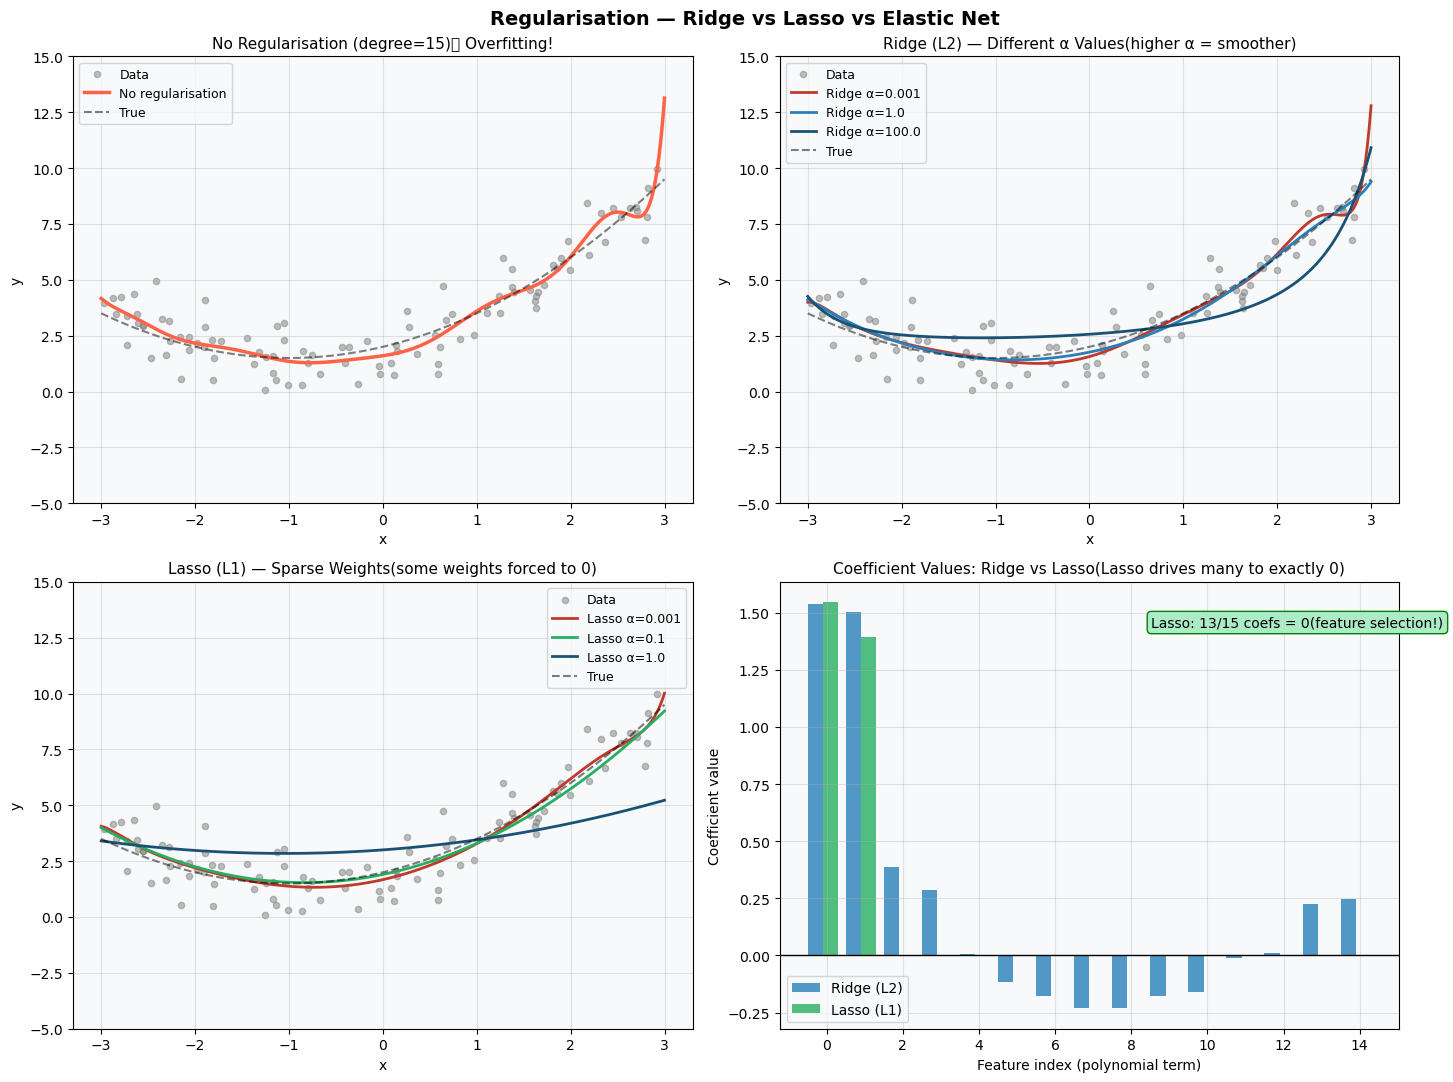

In [11]:
# Compare Ridge, Lasso and Elastic Net regularisation
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# Use high-degree polynomial to create an overfitting scenario
degree = 15    # Very flexible model — will overfit without regularisation

X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)  # Fine grid for smooth curves

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Regularisation — Ridge vs Lasso vs Elastic Net", fontsize=14, fontweight='bold')

# ── Top-left: No regularisation (baseline — overfitting) ────────────────
ax = axes[0, 0]
model_none = Pipeline([
    ('poly',   PolynomialFeatures(degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lin',    LinearRegression())
])
model_none.fit(X_poly, y_poly)
ax.scatter(X_poly, y_poly, color='gray', s=20, alpha=0.5, label='Data')
ax.plot(X_plot, model_none.predict(X_plot), 'tomato', lw=2.5, label='No regularisation')
ax.plot(X_plot, 0.5*X_plot**2 + X_plot + 2, 'k--', lw=1.5, alpha=0.5, label='True')
ax.set_ylim(-5, 15); ax.set_title(f"No Regularisation (degree={degree})❌ Overfitting!", fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel("x"); ax.set_ylabel("y")

# ── Ridge: different alpha values ───────────────────────────────────────
ax = axes[0, 1]
ax.scatter(X_poly, y_poly, color='gray', s=20, alpha=0.5, label='Data')
for alpha, color in [(0.001, '#C0392B'), (1.0, '#2980B9'), (100.0, '#1A5276')]:
    ridge = Pipeline([
        ('poly',   PolynomialFeatures(degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=alpha))   # alpha controls regularisation strength
    ])
    ridge.fit(X_poly, y_poly)
    ax.plot(X_plot, ridge.predict(X_plot), lw=2, label=f'Ridge α={alpha}', color=color)
ax.plot(X_plot, 0.5*X_plot**2 + X_plot + 2, 'k--', lw=1.5, alpha=0.5, label='True')
ax.set_ylim(-5, 15); ax.set_title("Ridge (L2) — Different α Values(higher α = smoother)", fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel("x"); ax.set_ylabel("y")

# ── Lasso: drives some coefficients to zero ─────────────────────────────
ax = axes[1, 0]
ax.scatter(X_poly, y_poly, color='gray', s=20, alpha=0.5, label='Data')
for alpha, color in [(0.001, '#C0392B'), (0.1, '#27AE60'), (1.0, '#1A5276')]:
    lasso = Pipeline([
        ('poly',   PolynomialFeatures(degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso',  Lasso(alpha=alpha, max_iter=10000))  # max_iter increased for convergence
    ])
    lasso.fit(X_poly, y_poly)
    y_lasso = lasso.predict(X_plot)
    # Clip extreme values for visual clarity
    ax.plot(X_plot, np.clip(y_lasso, -5, 15), lw=2, label=f'Lasso α={alpha}', color=color)
ax.plot(X_plot, 0.5*X_plot**2 + X_plot + 2, 'k--', lw=1.5, alpha=0.5, label='True')
ax.set_ylim(-5, 15); ax.set_title("Lasso (L1) — Sparse Weights(some weights forced to 0)", fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel("x"); ax.set_ylabel("y")

# ── Coefficient comparison: Ridge vs Lasso ──────────────────────────────
ax = axes[1, 1]
ridge_best = Pipeline([('poly', PolynomialFeatures(degree, include_bias=False)),
                        ('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
lasso_best = Pipeline([('poly', PolynomialFeatures(degree, include_bias=False)),
                        ('scaler', StandardScaler()), ('model', Lasso(alpha=0.1, max_iter=10000))])
ridge_best.fit(X_poly, y_poly)
lasso_best.fit(X_poly, y_poly)

ridge_coefs = ridge_best.named_steps['model'].coef_   # Learned weight vector (Ridge)
lasso_coefs = lasso_best.named_steps['model'].coef_   # Learned weight vector (Lasso)
idx = np.arange(len(ridge_coefs))

ax.bar(idx - 0.3, ridge_coefs, 0.4, label='Ridge (L2)', color='#2980B9', alpha=0.8)
ax.bar(idx + 0.1, lasso_coefs, 0.4, label='Lasso (L1)', color='#27AE60', alpha=0.8)
ax.axhline(0, color='black', lw=1)
ax.set_title("Coefficient Values: Ridge vs Lasso(Lasso drives many to exactly 0)",
             fontsize=11)
ax.set_xlabel("Feature index (polynomial term)")
ax.set_ylabel("Coefficient value")
ax.legend()
zero_lasso = (np.abs(lasso_coefs) < 1e-6).sum()   # Count truly-zero Lasso coefficients
ax.text(0.6, 0.9, f"Lasso: {zero_lasso}/{len(lasso_coefs)} coefs = 0(feature selection!)",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', fc='#ABEBC6', ec='green'))

plt.tight_layout()
plt.savefig("ch04_06_regularisation.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. 📊 Logistic Regression

Up to now we've only done regression. Now we use a similar linear model for **classification**.

> 🟦 **Logistic Regression:** Despite its name, it's a **classification** algorithm. It estimates the **probability** that an instance belongs to the positive class, using the sigmoid function.

### The Sigmoid Function

$$\sigma(t) = \frac{1}{1 + e^{-t}}$$

- Takes any number as input and squashes it to the range (0, 1)
- Output is interpreted as a **probability**
- If $\sigma(t) \geq 0.5$ -> predict class 1; otherwise -> predict class 0

### The full model:
$$\hat{p} = \sigma(\boldsymbol{\theta}^T \mathbf{x}) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \cdots)}}$$

> 🟦 **Log-Loss (Cross-Entropy):** The cost function for Logistic Regression — penalises confident wrong predictions very heavily.
> $$J(\boldsymbol{\theta}) = -\frac{1}{m} \sum \left[ y^{(i)} \log(\hat{p}^{(i)}) + (1-y^{(i)}) \log(1-\hat{p}^{(i)}) \right]$$


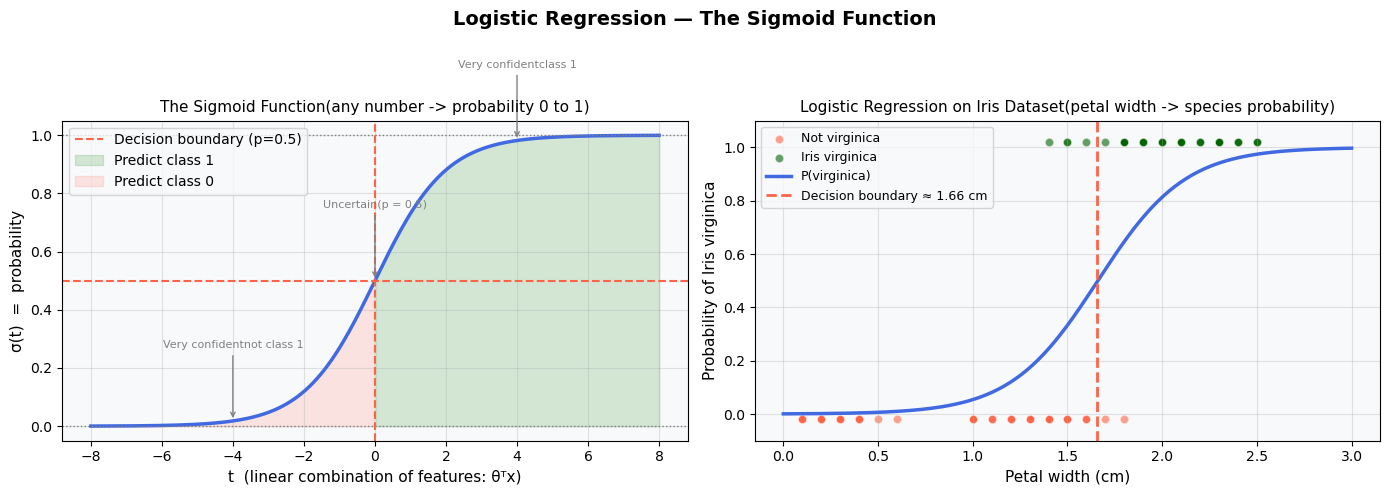

In [12]:
# Visualise the sigmoid function
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(-8, 8, 300)                  # Range of input values
sigmoid = 1 / (1 + np.exp(-t))               # σ(t) = 1 / (1 + e^{-t})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Logistic Regression — The Sigmoid Function", fontsize=14, fontweight='bold')

# ── Left: sigmoid curve ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(t, sigmoid, 'royalblue', lw=2.5)
ax.axhline(0.5, color='tomato', lw=1.5, linestyle='--', label='Decision boundary (p=0.5)')
ax.axhline(0,   color='gray',   lw=1,   linestyle=':')   # Lower asymptote
ax.axhline(1,   color='gray',   lw=1,   linestyle=':')   # Upper asymptote
ax.axvline(0,   color='tomato', lw=1.5, linestyle='--')   # t=0 maps to p=0.5

# Shade the two decision regions
ax.fill_between(t, 0, sigmoid, where=(sigmoid >= 0.5), alpha=0.15, color='green',  label='Predict class 1')
ax.fill_between(t, 0, sigmoid, where=(sigmoid < 0.5),  alpha=0.15, color='tomato', label='Predict class 0')

ax.set_xlabel("t  (linear combination of features: θᵀx)", fontsize=11)
ax.set_ylabel("σ(t)  =  probability", fontsize=11)
ax.set_title("The Sigmoid Function(any number -> probability 0 to 1)", fontsize=11)
ax.legend(); ax.set_ylim(-0.05, 1.05)

# Annotate key points
for t_val, p_val, label in [(-4, 1/(1+np.exp(4)), 'Very confidentnot class 1'),
                              (0,  0.5,              'Uncertain(p = 0.5)'),
                              (4,  1/(1+np.exp(-4)), 'Very confidentclass 1')]:
    ax.annotate(label, xy=(t_val, p_val), xytext=(t_val, p_val+0.25),
                ha='center', fontsize=8, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# ── Right: fit on a real dataset (Iris: petal width predicts species) ────
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()                             # Famous 3-class flower dataset
X_iris = iris.data[:, 3:4]                    # Use only petal width (column 3) as feature
y_iris = (iris.target == 2).astype(int)       # Binary: 1 = Iris virginica, 0 = anything else

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_iris, y_iris)                   # Fit logistic regression

X_range = np.linspace(0, 3, 300).reshape(-1, 1)  # Petal width range for smooth curve
y_proba = log_reg.predict_proba(X_range)[:, 1]   # P(Iris virginica | petal width)
# predict_proba -> returns [[P(class 0), P(class 1)], ...]
# [:, 1]        -> take only P(class 1) = P(Iris virginica)

ax = axes[1]
ax.scatter(X_iris[y_iris==0], y_iris[y_iris==0]-0.02,
           color='tomato', edgecolors='white', s=40, alpha=0.6, label='Not virginica')
ax.scatter(X_iris[y_iris==1], y_iris[y_iris==1]+0.02,
           color='darkgreen', edgecolors='white', s=40, alpha=0.6, label='Iris virginica')
ax.plot(X_range, y_proba, 'royalblue', lw=2.5, label='P(virginica)')

# Decision boundary: where probability = 0.5
decision_boundary = X_range[np.argmin(np.abs(y_proba - 0.5))][0]
ax.axvline(decision_boundary, color='tomato', lw=2, linestyle='--',
           label=f'Decision boundary ≈ {decision_boundary:.2f} cm')

ax.set_xlabel("Petal width (cm)", fontsize=11)
ax.set_ylabel("Probability of Iris virginica", fontsize=11)
ax.set_title("Logistic Regression on Iris Dataset(petal width -> species probability)", fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig("ch04_07_logistic_regression.png", dpi=150, bbox_inches='tight')
plt.show()


Logistic Regression — Binary Classification (Iris virginica)
               precision    recall  f1-score   support

Not virginica       1.00      1.00      1.00        19
    Virginica       1.00      1.00      1.00        11

     accuracy                           1.00        30
    macro avg       1.00      1.00      1.00        30
 weighted avg       1.00      1.00      1.00        30



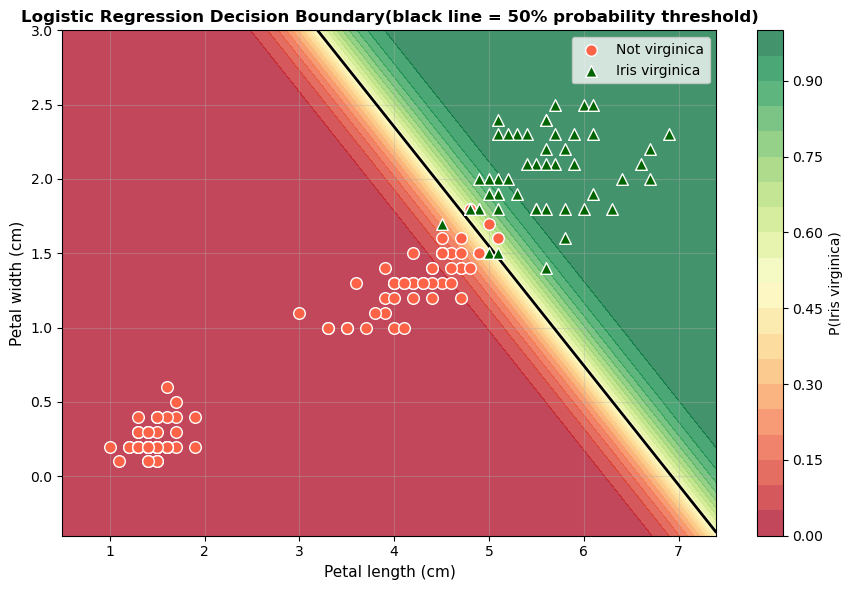

In [13]:
# Full logistic regression — two features, visualise the decision boundary
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X_2d   = iris.data[:, 2:4]       # Use petal length + petal width (columns 2 and 3)
y_bin  = (iris.target == 2).astype(int)   # Binary: Iris virginica vs rest

X_tr, X_te, y_tr, y_te = train_test_split(X_2d, y_bin, test_size=0.2, random_state=42)
log_reg_2d = LogisticRegression(C=10, random_state=42)  # C = 1/alpha (higher C = less regularisation)
log_reg_2d.fit(X_tr, y_tr)

print("Logistic Regression — Binary Classification (Iris virginica)")
print(classification_report(y_te, log_reg_2d.predict(X_te),
                             target_names=['Not virginica', 'Virginica']))

# ── Visualise the decision boundary ────────────────────────────────────
x0_min, x0_max = X_2d[:, 0].min()-0.5, X_2d[:, 0].max()+0.5  # Range for petal length
x1_min, x1_max = X_2d[:, 1].min()-0.5, X_2d[:, 1].max()+0.5  # Range for petal width
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                        np.linspace(x1_min, x1_max, 300))
# np.meshgrid -> creates a fine grid of (x0, x1) coordinate pairs

grid_points = np.c_[xx0.ravel(), xx1.ravel()]   # Shape (300×300, 2) — all grid points
Z_proba = log_reg_2d.predict_proba(grid_points)[:, 1].reshape(xx0.shape)
# Predict P(virginica) for every point in the grid

fig, ax = plt.subplots(figsize=(9, 6))
contour = ax.contourf(xx0, xx1, Z_proba, levels=20,
                      cmap='RdYlGn', alpha=0.75, vmin=0, vmax=1)
plt.colorbar(contour, ax=ax, label='P(Iris virginica)')
ax.contour(xx0, xx1, Z_proba, levels=[0.5],
           colors='black', linewidths=2)   # Draw the exact decision boundary at p=0.5

# Plot the data points
for cls, label, color, marker in [(0, 'Not virginica', 'tomato', 'o'),
                                    (1, 'Iris virginica', 'darkgreen', '^')]:
    mask = y_bin == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, edgecolors='white',
               s=70, marker=marker, label=label, zorder=5)

ax.set_xlabel("Petal length (cm)", fontsize=11)
ax.set_ylabel("Petal width (cm)", fontsize=11)
ax.set_title("Logistic Regression Decision Boundary(black line = 50% probability threshold)", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("ch04_08_decision_boundary.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. 🔟 Softmax Regression — Multiclass Logistic Regression

> 🟦 **Softmax Regression (Multinomial Logistic Regression):** Extends Logistic Regression to handle **multiple classes directly** (without OvR). It outputs a probability for *each* class that all sum to 1.

### How it works:
1. Compute a score for each class: $s_k(\mathbf{x}) = \boldsymbol{\theta}_k^T \mathbf{x}$
2. Apply the **Softmax function** to convert scores to probabilities:
$$\hat{p}_k = \frac{e^{s_k(\mathbf{x})}}{\sum_{j=1}^{K} e^{s_j(\mathbf{x})}}$$
3. Predict the class with the **highest probability**

> 🟦 **Softmax Function:** Takes a vector of raw scores and converts them to a valid probability distribution (all positive, sum to 1).

> 🟨 **Key Takeaway:** Logistic Regression handles 2 classes. Softmax handles K classes. In Scikit-Learn, set `multi_class='multinomial'` (or just `solver='lbfgs'`).


Softmax Regression — 3-Class Iris Classification
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



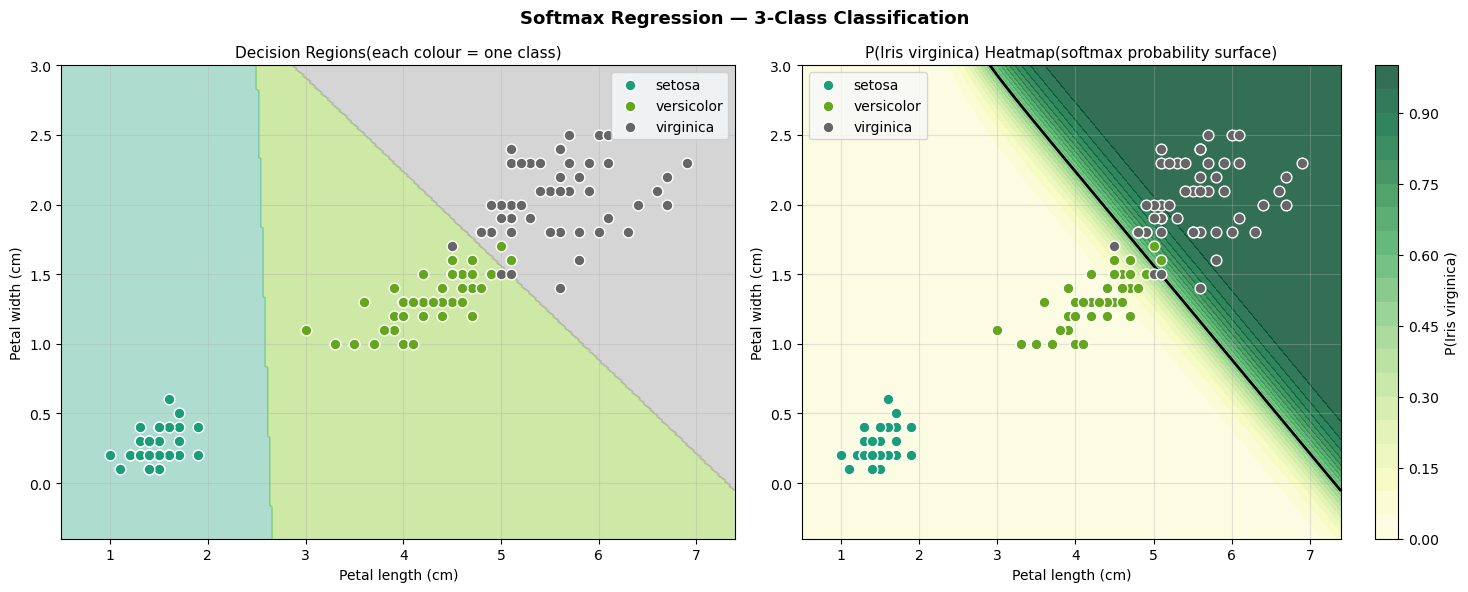

In [14]:
# Softmax Regression — classify all 3 Iris species at once
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

iris   = load_iris()
X_soft = iris.data[:, 2:4]    # Petal length + petal width
y_soft = iris.target           # 3 classes: 0=setosa, 1=versicolor, 2=virginica

X_tr, X_te, y_tr, y_te = train_test_split(X_soft, y_soft, test_size=0.2, random_state=42)

softmax_reg = LogisticRegression(
    multi_class='multinomial',   # Use Softmax instead of OvR
    solver='lbfgs',              # L-BFGS: an efficient optimiser for logistic regression
    C=10,                        # C=10 -> mild regularisation
    max_iter=1000,               # Maximum optimisation iterations
    random_state=42
)
softmax_reg.fit(X_tr, y_tr)    # Train on the 3-class problem

print("Softmax Regression — 3-Class Iris Classification")
print(classification_report(y_te, softmax_reg.predict(X_te),
                             target_names=iris.target_names))

# ── Visualise multiclass probability regions ────────────────────────────
x0_min, x0_max = X_soft[:, 0].min()-0.5, X_soft[:, 0].max()+0.5
x1_min, x1_max = X_soft[:, 1].min()-0.5, X_soft[:, 1].max()+0.5
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                        np.linspace(x1_min, x1_max, 300))
Z = softmax_reg.predict(np.c_[xx0.ravel(), xx1.ravel()]).reshape(xx0.shape)
# predict() returns the class with highest softmax probability for each grid point

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Softmax Regression — 3-Class Classification", fontsize=13, fontweight='bold')

# ── Left: decision regions ──────────────────────────────────────────────
ax = axes[0]
cmap_bg  = plt.cm.get_cmap('Set2', 3)    # 3 distinct background colours
cmap_pts = plt.cm.get_cmap('Dark2', 3)  # Darker colours for data points
ax.contourf(xx0, xx1, Z, cmap=cmap_bg, alpha=0.5)   # Colour-code decision regions

for cls in range(3):
    mask = y_soft == cls
    ax.scatter(X_soft[mask, 0], X_soft[mask, 1],
               c=[cmap_pts(cls)], edgecolors='white', s=60, zorder=5,
               label=iris.target_names[cls])

ax.set_xlabel("Petal length (cm)"); ax.set_ylabel("Petal width (cm)")
ax.set_title("Decision Regions(each colour = one class)", fontsize=11)
ax.legend()

# ── Right: probability for one class (Virginica) as a heatmap ───────────
ax = axes[1]
Z_proba = softmax_reg.predict_proba(np.c_[xx0.ravel(), xx1.ravel()])[:, 2].reshape(xx0.shape)
# predict_proba returns [[P(setosa), P(versicolor), P(virginica)], ...]
# [:, 2] -> P(virginica) for every grid point
cf = ax.contourf(xx0, xx1, Z_proba, levels=20, cmap='YlGn', alpha=0.8, vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='P(Iris virginica)')
ax.contour(xx0, xx1, Z_proba, levels=[0.5], colors='black', linewidths=2)

for cls in range(3):
    mask = y_soft == cls
    ax.scatter(X_soft[mask, 0], X_soft[mask, 1],
               c=[cmap_pts(cls)], edgecolors='white', s=60, zorder=5,
               label=iris.target_names[cls])
ax.set_xlabel("Petal length (cm)"); ax.set_ylabel("Petal width (cm)")
ax.set_title("P(Iris virginica) Heatmap(softmax probability surface)", fontsize=11)
ax.legend()

plt.tight_layout()
plt.savefig("ch04_09_softmax.png", dpi=150, bbox_inches='tight')
plt.show()


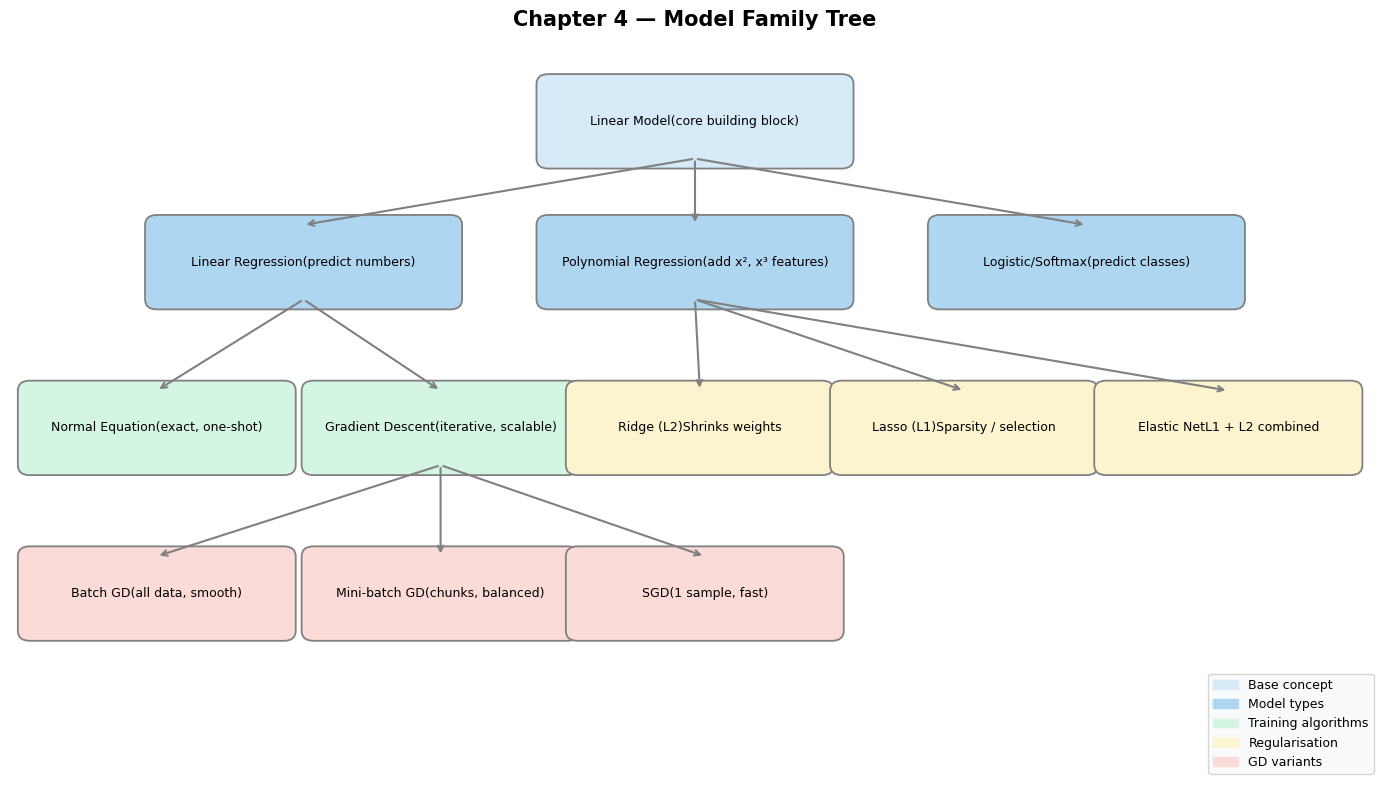

In [16]:
# Chapter summary: all models side by side on one figure
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14); ax.set_ylim(0, 9); ax.axis('off')
ax.set_title("Chapter 4 — Model Family Tree", fontsize=15, fontweight='bold')

boxes = [
    # (x, y, width, height, label, colour)
    (5.5, 7.5, 3, 0.9, "Linear Model(core building block)", "#D6EAF8"),

    (1.5, 5.8, 3, 0.9, "Linear Regression(predict numbers)", "#AED6F1"),
    (5.5, 5.8, 3, 0.9, "Polynomial Regression(add x², x³ features)", "#AED6F1"),
    (9.5, 5.8, 3, 0.9, "Logistic/Softmax(predict classes)", "#AED6F1"),

    (0.2, 3.8, 2.6, 0.9, "Normal Equation(exact, one-shot)", "#D5F5E3"),
    (3.1, 3.8, 2.6, 0.9, "Gradient Descent(iterative, scalable)", "#D5F5E3"),
    (5.8, 3.8, 2.5, 0.9, "Ridge (L2)Shrinks weights", "#FCF3CF"),
    (8.5, 3.8, 2.5, 0.9, "Lasso (L1)Sparsity / selection", "#FCF3CF"),
    (11.2,3.8, 2.5, 0.9, "Elastic NetL1 + L2 combined", "#FCF3CF"),

    (0.2, 1.8, 2.6, 0.9, "Batch GD(all data, smooth)", "#FADBD8"),
    (3.1, 1.8, 2.6, 0.9, "Mini-batch GD(chunks, balanced)", "#FADBD8"),
    (5.8, 1.8, 2.6, 0.9, "SGD(1 sample, fast)", "#FADBD8"),
]

for (x, y, w, h, label, color) in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.12", fc=color, ec='gray', lw=1.3))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=9)

# Arrows from top to second row
for x_to in [3.0, 7.0, 11.0]:
    ax.annotate("", xy=(x_to, 6.7), xytext=(7.0, 7.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrow from Linear Regression to optimisers
for x_from, x_to in [(3.0, 1.5), (3.0, 4.4)]:
    ax.annotate("", xy=(x_to, 4.7), xytext=(3.0, 5.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrow from GD to its variants
for x_to in [1.5, 4.4, 7.1]:
    ax.annotate("", xy=(x_to, 2.7), xytext=(4.4, 3.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrow from Polynomial to regularisation
for x_to in [7.05, 9.75, 12.45]:
    ax.annotate("", xy=(x_to, 4.7), xytext=(7.0, 5.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Legend patches
legend_patches = [
    mpatches.Patch(color="#D6EAF8", label="Base concept"),
    mpatches.Patch(color="#AED6F1", label="Model types"),
    mpatches.Patch(color="#D5F5E3", label="Training algorithms"),
    mpatches.Patch(color="#FCF3CF", label="Regularisation"),
    mpatches.Patch(color="#FADBD8", label="GD variants"),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("ch04_10_summary.png", dpi=150, bbox_inches='tight')
plt.show()


## 📖 Chapter 4 Key Terminology Glossary

| Term | Simple Definition |
|---|---|
| **Bias (θ₀)** | The y-intercept — the model's baseline prediction when all features are zero |
| **Weight / Coefficient** | How much a feature moves the prediction (slope in 1D) |
| **Normal Equation** | Direct closed-form formula for optimal weights — no iteration needed |
| **Gradient Descent** | Iterative algorithm: follow the slope of the cost function downhill |
| **Learning Rate (η)** | Step size in gradient descent — too small = slow, too big = overshoots |
| **Epoch** | One full pass through the entire training dataset |
| **Batch GD** | Uses all training data for each parameter update — smooth but slow |
| **Stochastic GD (SGD)** | Uses 1 random sample per update — fast but noisy |
| **Mini-batch GD** | Uses a small random batch per update — best of both worlds |
| **MSE** | Mean Squared Error — the cost function linear regression minimises |
| **Polynomial Features** | Adding x², x³ etc. to let a linear model fit curves |
| **Learning Curve** | Plot of error vs training set size — reveals bias/variance problem |
| **Regularisation** | Penalising large weights to prevent overfitting |
| **Ridge (L2)** | Adds sum of squared weights to cost — shrinks all weights |
| **Lasso (L1)** | Adds sum of absolute weights — drives some weights to exactly zero |
| **Elastic Net** | Combines L1 + L2 regularisation |
| **Alpha (α)** | Regularisation strength — higher = more penalty, simpler model |
| **Sigmoid Function** | Squashes any number to (0,1) — converts score to probability |
| **Logistic Regression** | Linear model for binary classification using sigmoid |
| **Log-Loss** | Cost function for logistic regression (cross-entropy) |
| **Softmax Regression** | Multiclass logistic regression — one probability per class |
| **Decision Boundary** | The line/surface where the model switches its predicted class |

---

## 🟨 Chapter 4 Key Takeaways

> 1. **Linear Regression** finds the best-fit line by minimising MSE — either exactly (Normal Equation) or iteratively (Gradient Descent)
> 2. **Gradient Descent** is the universal learning engine — it works by following the slope of the cost function downhill
> 3. **Learning rate matters enormously** — too small wastes time, too large diverges
> 4. **Mini-batch GD** is the practical sweet spot between batch and stochastic
> 5. **Polynomial features** let linear models fit curves — but watch out for overfitting
> 6. **Learning curves** diagnose whether you have a bias (underfitting) or variance (overfitting) problem
> 7. **Regularisation** (Ridge/Lasso/Elastic Net) is the main tool to fight overfitting
> 8. **Logistic Regression** outputs probabilities via sigmoid — ideal for binary classification
> 9. **Softmax Regression** extends this to multiple classes natively

---
*Next up -> Chapter 5: Support Vector Machines (SVMs) 🎯*
